# MV-4571 — EP Imbalance Analysis for GLM-5.2-FP8 (DP8 / EP8)

Phân tích mức độ **expert-parallel (EP) imbalance** khi serve `GLM-5.2-FP8` trên vLLM.

## Data được collect như thế nào
Server chạy với `VLLM_MOREH_EP_LOG=1`. Patch nằm ở `fp8.py::Fp8MoEMethod.apply` — ngay **trước khi gọi `moe_kernel.apply` (tức trước all2all/dispatch trong `_prepare`)**. Mỗi MoE-forward log ra:

```
(Worker_DP3_EP3 pid=...) INFO ... [fp8.py:NNN] [EP_COLLECT] layer=<name> it=<k> ntok=<local_tokens> E=<num_experts> counts=[c0,...,c255]
```

- `counts` = bincount của `topk_ids` trên **GLOBAL expert space (256)**, tính trên các token *local* của riêng DP-rank đó (trước all2all).
- `rank` lấy từ prefix `(Worker_DPx_EPx ...)` do multiproc-executor gắn vào mỗi dòng log.
- `it` = bộ đếm forward theo từng `(process, layer)` — dùng để căn step giữa các rank (các DP-rank chạy forward lockstep).

## Cách tính imbalance
Tại **mỗi (layer, step)**, ta cộng histogram local của **tất cả 8 DP-rank** → global histogram `g[0..255]` (số (token,slot) chọn mỗi expert trên toàn batch). Expert `e` nằm ở EP-rank `e // (E/R)`, nên **tải của rank `r`** (số token-routing rank đó phải xử lý sau dispatch) = tổng `g[e]` trong block expert của rank.

- `imbalance = max(load) / min(load)`  (theo yêu cầu ticket)
- phụ: `max/avg` (room-for-improvement) và expert-level `max/avg`.

## Prefill / mixed vs Decode
Phân loại theo `num_tokens` global của step (`sum(g)/topk`). Decode: tổng token nhỏ (≈ số seq đang chạy ≈ concurrency). Prefill/mixed: chunk lớn hơn.

In [1]:
# =============================================================================
# CELL 1 — CONFIG: khai báo đường dẫn log + các tham số phân tích.
# Tất cả hằng số "cần chỉnh tay" gom hết ở đây để các cell sau chỉ việc dùng.
# =============================================================================
import os, re, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------- CONFIG -----------------------------
# Case đang phân tích: noMTP, ISL 8k, OSL 1024, rate=inf, conc=8.
#
# LOG_GLOB: mẫu đường dẫn tới serve.log.
#   - Để "*" ở chỗ timestamp (.../auto_bench/*/serve.log) thì dòng glob bên dưới
#     sẽ tự lấy run MỚI NHẤT (sort theo tên thư mục timestamp -> phần tử cuối).
#   - Hoặc trỏ thẳng 1 run cụ thể như hiện tại.
LOG_GLOB = "/home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_bench/20260625_040651_8k_c8/serve.log"
LOG_PATH = sorted(glob.glob(LOG_GLOB))[-1]   # lấy file mới nhất khớp mẫu

# Mốc bắt đầu collect: chỉ phân tích các dòng log SAU khi server đã sẵn sàng.
# (bỏ qua toàn bộ dummy-forward / profiling / warmup lúc khởi động.)
STARTUP_MARKER = "Application startup complete."
USE_LAST_MARKER = True            # True = dùng lần xuất hiện CUỐI CÙNG của marker (an toàn nhất với DP nhiều engine)

# Tham số mô hình/run dùng cho phân loại & nhãn (không ảnh hưởng parse).
CONCURRENCY   = 8                 # số request đồng thời của case này
DECODE_MAX_TOKENS = 72            # step có num_tokens(global) <= ngưỡng => decode; còn lại => prefill/mixed.
                                  # => xem histogram tokens/step ở CELL 6 rồi chỉnh cho khớp 2 cụm.

print("LOG_PATH =", LOG_PATH)
print("size     =", os.path.getsize(LOG_PATH) / 1e6, "MB")

LOG_PATH = /home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_bench/20260625_040651_8k_c8/serve.log
size     = 1116.768118 MB


## 1. Parse logs (sau startup) + aggregate qua các DP-rank

3 lần đọc file (streaming, low-mem):
1. tìm dòng `Application startup complete.` cuối cùng → `cut_line`.
2. pass A: tính `min(it)` theo `(rank, layer)` để chuẩn hoá `step = it - min_it` (bỏ offset startup khác nhau giữa rank).
3. pass B: cộng `counts` qua các rank cho mỗi `(layer, step)`.

In [2]:
# =============================================================================
# CELL 3 — PARSE log + AGGREGATE qua các DP-rank.
# Đọc serve.log 3 lần (streaming, ít RAM) để biến hàng triệu dòng [EP_COLLECT]
# thành dict: (layer, step) -> histogram global g[256] (đã cộng đủ 8 rank).
# =============================================================================

# --- Regex 1: bóc các trường từ 1 dòng [EP_COLLECT] ---
#   group(1)=DP rank, group(2)=EP rank, group(3)=layer_name,
#   group(4)=it (bộ đếm forward), group(5)=ntok (token local), group(6)=E (=256).
#   Regex DỪNG ngay sau "counts=[" -> phần số trong [...] sẽ tự cắt bằng find("]") cho nhanh.
HEADER_RE = re.compile(
    r"Worker_DP(\d+)_EP(\d+).*?\[EP_COLLECT\] layer=(\S+) it=(\d+) ntok=(\d+) E=(\d+) counts=\["
)
# --- Regex 2: lấy chỉ số layer từ layer_name, vd "model.layers.5.mlp" -> 5 ---
LAYER_IDX_RE = re.compile(r"layers\.(\d+)")


def find_cut_line(path, marker, use_last=True):
    """Tìm số thứ tự dòng của marker startup. Chỉ collect các dòng SAU dòng này.
    use_last=True -> lấy lần xuất hiện cuối (chắc chắn mọi engine đã ready)."""
    cut = -1
    with open(path, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if marker in line:
                cut = i
                if not use_last:
                    break
    return cut


def parse_and_aggregate(path, marker=STARTUP_MARKER, use_last=USE_LAST_MARKER):
    cut = find_cut_line(path, marker, use_last)
    print(f"startup '{marker}' at line {cut} (collect strictly after this)")

    # ----------------------------------------------------------------------
    # PASS A: tính min(it) cho mỗi (rank, layer).
    # Vì mỗi process đếm `it` từ lúc khởi động (gồm cả dummy-forward trước cut),
    # nên offset đầu của mỗi rank có thể khác nhau. Ta lấy min(it) sau cut để
    # chuẩn hoá: step = it - min_it  => step 0 = forward THỰC đầu tiên của mọi rank
    # => cùng 1 step thực sẽ khớp nhau giữa 8 rank khi cộng.
    # ----------------------------------------------------------------------
    min_it = {}
    ranks_seen, layers_seen, E_seen = set(), set(), set()
    with open(path, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if i <= cut:                       # bỏ mọi dòng trước/đúng dòng startup
                continue
            m = HEADER_RE.search(line)
            if not m:                          # dòng không phải [EP_COLLECT]
                continue
            ep = int(m.group(2))               # EP rank (TP=1 => DP==EP)
            lname = m.group(3)
            it = int(m.group(4))
            E_seen.add(int(m.group(6)))        # gom E để tự suy num_experts
            lm = LAYER_IDX_RE.search(lname)
            if not lm:
                continue
            lidx = int(lm.group(1))
            ranks_seen.add(ep); layers_seen.add(lidx)
            k = (ep, lidx)
            if k not in min_it or it < min_it[k]:
                min_it[k] = it                 # giữ it nhỏ nhất theo (rank, layer)

    R = len(ranks_seen)                        # số rank quan sát được (kỳ vọng 8)
    E = max(E_seen) if E_seen else 0           # số expert global (kỳ vọng 256)
    assert R > 0 and E > 0, "No [EP_COLLECT] lines found after startup marker"
    print(f"ranks(R)={R} ranks={sorted(ranks_seen)}  experts(E)={E}  moe_layers={len(layers_seen)}")

    # ----------------------------------------------------------------------
    # PASS B: cộng counts của tất cả rank cho mỗi (layer, step).
    #   agg[(layer,step)]       = g[256]  (histogram global)
    #   agg_ranks[(layer,step)] = tập rank đã góp -> để biết group đã đủ R rank chưa
    #   agg_ntok[(layer,step)]  = tổng token local qua các rank (chưa /topk)
    # ----------------------------------------------------------------------
    agg = {}
    agg_ranks = {}
    agg_ntok = {}
    topk_samples = []                          # để suy topk = sum(counts)/ntok
    with open(path, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if i <= cut:
                continue
            m = HEADER_RE.search(line)
            if not m:
                continue
            ep = int(m.group(2))
            lname = m.group(3)
            it = int(m.group(4))
            ntok = int(m.group(5))
            lm = LAYER_IDX_RE.search(lname)
            if not lm:
                continue
            lidx = int(lm.group(1))
            # Lấy chuỗi số nằm giữa "counts=[" (= m.end()) và "]" gần nhất, rồi parse.
            start = m.end()
            rb = line.find("]", start)
            if rb == -1:                       # dòng bị cắt/hỏng -> bỏ
                continue
            counts = np.array(line[start:rb].split(","), dtype=np.int64)
            if counts.shape[0] != E:           # độ dài bất thường -> bỏ cho an toàn
                raise Exception()
            step = it - min_it[(ep, lidx)]     # <-- chuẩn hoá step (xem PASS A)
            key = (lidx, step)
            if key not in agg:                 # group mới -> khởi tạo
                agg[key] = counts.copy()
                agg_ranks[key] = {ep}
                agg_ntok[key] = ntok
            else:                              # group đã có -> cộng dồn rank này vào
                agg[key] += counts
                agg_ranks[key].add(ep)
                agg_ntok[key] += ntok
            if ntok > 0:
                topk_samples.append(counts.sum() / ntok)

    # topk = trung vị của (sum(counts)/ntok). GLM5.2 => kỳ vọng 8.
    topk = int(round(np.median(topk_samples))) if topk_samples else 0
    return agg, agg_ranks, agg_ntok, R, E, topk, sorted(layers_seen)


# Chạy parse. Kết quả dùng cho mọi cell sau.
agg, agg_ranks, agg_ntok, R, E, TOPK, MOE_LAYERS = parse_and_aggregate(LOG_PATH)
EXPERTS_PER_RANK = E // R          # 256/8 = 32 (giả định placement "linear" - đã verify EPLB tắt)
print(f"TOPK(inferred)={TOPK}  EXPERTS_PER_RANK={EXPERTS_PER_RANK}")
print(f"total (layer,step) groups = {len(agg)}")

startup 'Application startup complete.' at line 3281 (collect strictly after this)
ranks(R)=8 ranks=[0, 1, 2, 3, 4, 5, 6, 7]  experts(E)=256  moe_layers=75
TOPK(inferred)=8  EXPERTS_PER_RANK=32
total (layer,step) groups = 154198


In [3]:
# =============================================================================
# CELL 4 — Từ histogram global -> TẢI MỖI RANK + các chỉ số IMBALANCE.
# Mỗi (layer, step) thành 1 dòng trong steps_df. Đây là bảng dữ liệu lõi.
# =============================================================================

def rank_loads(counts, R):
    """Chia histogram global g[E] thành R block expert liên tục rồi sum mỗi block.
    => trả về vector R phần tử = số token-routing mỗi EP-rank phải xử lý sau dispatch.
    (Giả định placement 'linear': rank r sở hữu expert [r*E/R, (r+1)*E/R).)"""
    per = counts.shape[0] // R                 # experts/rank = 32
    assert counts.shape[0] % R == 0
    return counts[: per * R].reshape(R, per).sum(axis=1)

rows = []
expert_dist_global = np.zeros(E, dtype=np.int64)   # tích luỹ histogram cả run (cho CELL 12)
n_dropped = 0

for (lidx, step), counts in agg.items():
    # CHỈ giữ group đã đủ R rank. Group thiếu rank (thường ở biên startup, hoặc
    # rank lệch step) sẽ cho tải sai -> bỏ và đếm lại để mình kiểm soát.
    if len(agg_ranks[(lidx, step)]) != R:
        n_dropped += 1
        continue

    total = int(counts.sum())                  # tổng routing = num_tokens * topk
    if total == 0:
        continue
    
    loads = rank_loads(counts, R)              # tải 8 rank
    lmax = int(loads.max())
    lmin = max(int(loads.min()), 1)            # clamp >=1 để không chia 0
    lavg = total / R                           # tải trung bình lý tưởng (balanced)
    num_tokens = total / TOPK                  # số token GLOBAL của step này

    rows.append({
        "layer": lidx,
        "step": step,
        "num_tokens": num_tokens,
        "total_routings": total,
        "rank_max_over_min": lmax / lmin,                 # <-- METRIC CHÍNH (ticket): max/min
        "rank_max_over_avg": lmax / lavg,                 # room-for-improvement (>=1; 1.0 = hoàn hảo)
        "expert_max_over_avg": counts.max() / (total / E),# imbalance ở mức TỪNG expert
        "load_min": lmin,
        "load_max": lmax,
    })
    expert_dist_global += counts               # cộng vào phân phối tổng toàn run

# DataFrame lõi: mỗi dòng = 1 (layer, step).
steps_df = pd.DataFrame(rows)
# Gắn nhãn phase theo tổng token global của step.
steps_df["phase"] = np.where(steps_df["num_tokens"] <= DECODE_MAX_TOKENS, "decode", "prefill_mixed")

print(f"kept groups (full {R} ranks) = {len(steps_df)}   dropped (partial) = {n_dropped}")
print(steps_df["phase"].value_counts())
steps_df.head()



kept groups (full 8 ranks) = 154197   dropped (partial) = 1
phase
decode           153672
prefill_mixed       525
Name: count, dtype: int64


,layer,step,num_tokens,total_routings,rank_max_over_min,rank_max_over_avg,expert_max_over_avg,load_min,load_max,phase
0,3,0,8198.0,65584,9.689394,1.560137,31.609661,1320,12790,prefill_mixed
1,4,0,8198.0,65584,7.024357,1.899610,30.395706,2217,15573,prefill_mixed
2,5,0,8198.0,65584,5.844292,1.767260,31.929739,2479,14488,prefill_mixed
3,6,0,8198.0,65584,2.842820,1.584045,17.967309,4568,12986,prefill_mixed
4,7,0,8198.0,65584,3.000825,1.775311,21.675531,4850,14554,prefill_mixed


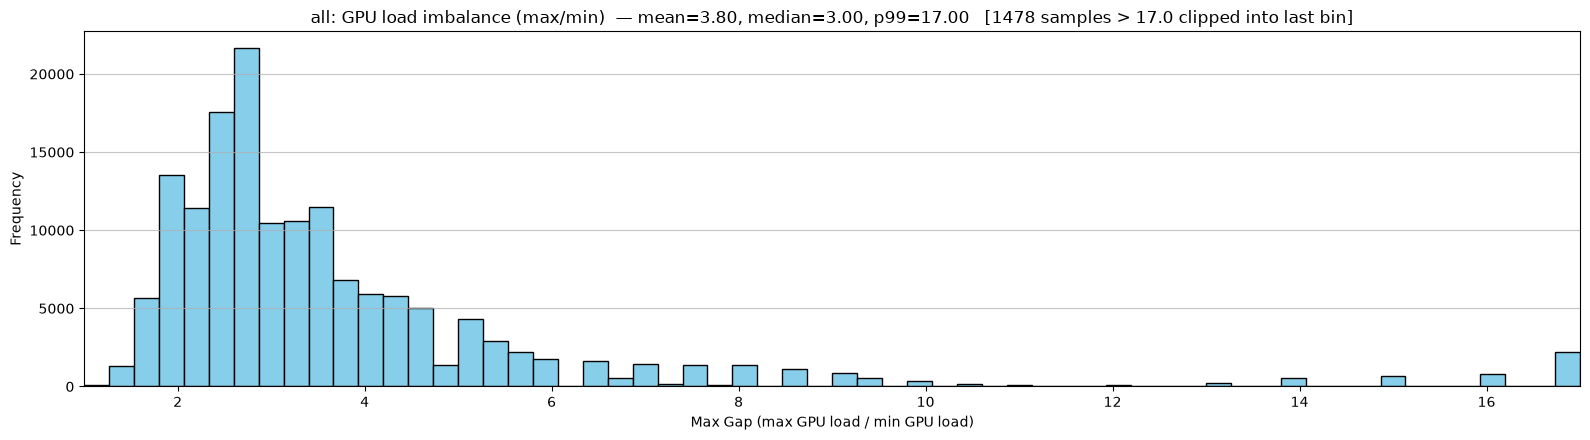

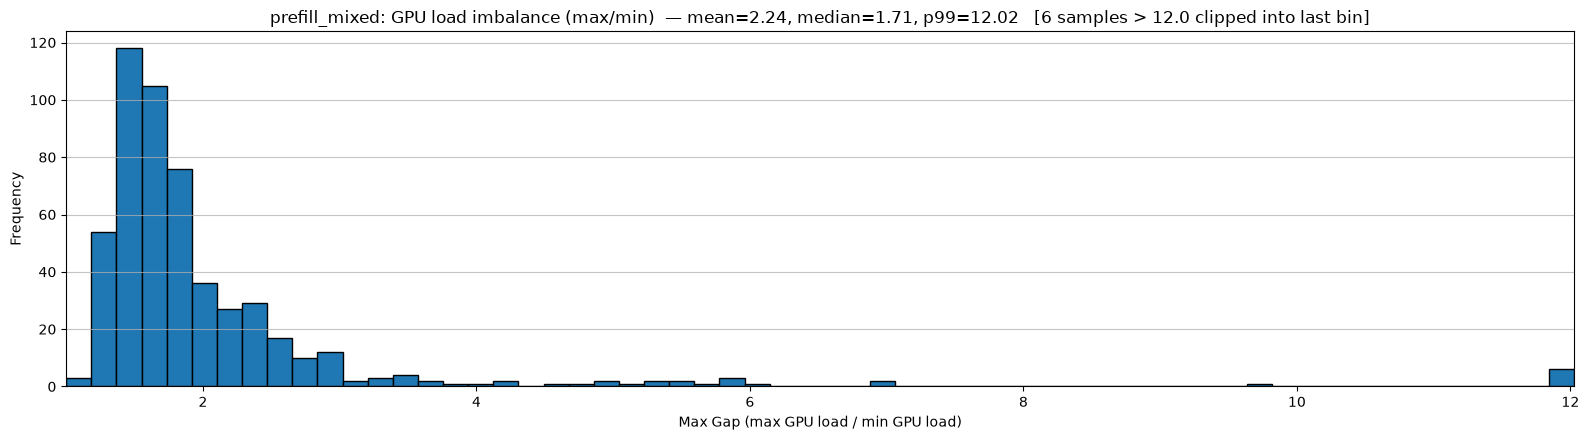

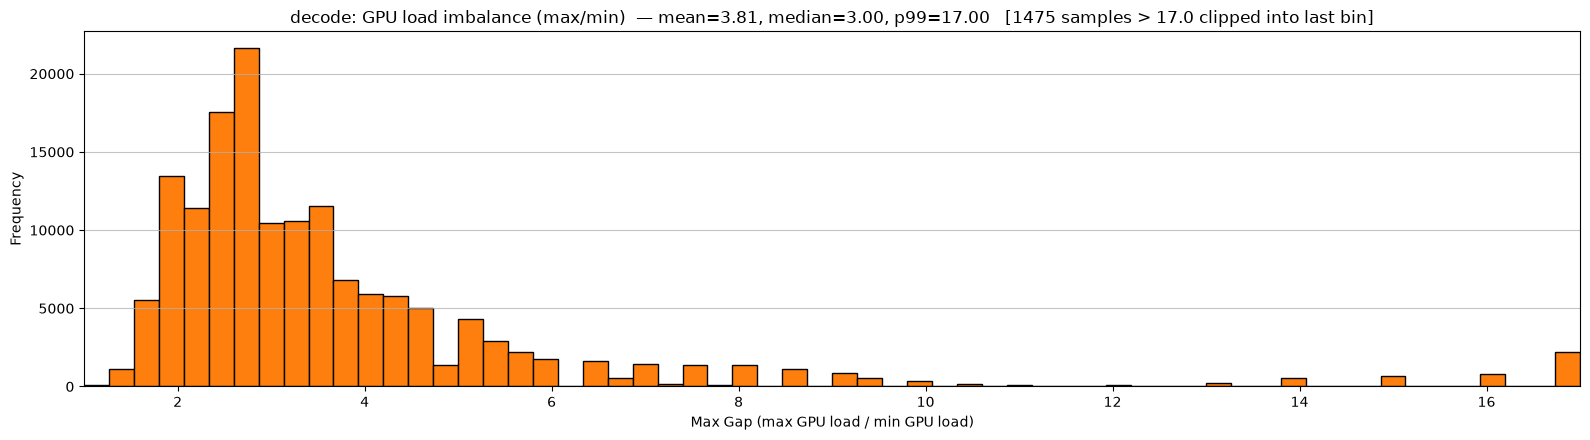

In [4]:
# =============================================================================
# CELL 5 — HISTOGRAM phân phối imbalance (max_gpu_load / min_gpu_load).
# Giống cell "Visualize gap distribution" trong process_ep_logs.ipynb.
# Vẽ 3 FIGURE RIÊNG (không subplot) -> trục x dài, dễ nhìn: all / prefill_mixed / decode.
# Mỗi mẫu = 1 (layer, step) trên TOÀN BỘ run.
#   trục x = max_gpu_load / min_gpu_load   (cột rank_max_over_min)
#   trục y = frequency (số mẫu)
# =============================================================================
# --- ZOOM trục x ---
#   X_MAX=None  -> tự cắt ở percentile X_CLIP_PCT của TỪNG subset (zoom vào phần đông).
#   X_MAX=<số>  -> cắt cứng tại giá trị này (vd 20).
# Giá trị > xmax được CLIP vào bin cuối (không mất mẫu).
X_MAX = None
X_CLIP_PCT = 99.0
N_BINS = 60
FIGSIZE = (16, 4.5)        # rộng để trục x dài

subsets = [
    ("all",            steps_df["rank_max_over_min"].values,                                   "skyblue"),
    ("prefill_mixed",  steps_df[steps_df.phase == "prefill_mixed"]["rank_max_over_min"].values, "#1f77b4"),
    ("decode",         steps_df[steps_df.phase == "decode"]["rank_max_over_min"].values,        "#ff7f0e"),
]

for name, vals, color in subsets:
    plt.figure(figsize=FIGSIZE)               # <-- mỗi subset 1 figure riêng
    if len(vals) == 0:
        plt.title(f"{name} (none)"); plt.show(); continue
    xmax = X_MAX if X_MAX is not None else max(2.0, float(np.percentile(vals, X_CLIP_PCT)))
    n_over = int((vals > xmax).sum())         # số mẫu bị dồn vào bin cuối
    vclip = np.clip(vals, 1.0, xmax)
    bins = np.linspace(1.0, xmax, N_BINS + 1)
    plt.hist(vclip, bins=bins, color=color, edgecolor="black")
    plt.xlim(1.0, xmax)
    title = (f"{name}: GPU load imbalance (max/min)  — "
             f"mean={vals.mean():.2f}, median={np.median(vals):.2f}, p99={np.percentile(vals, 99):.2f}")
    if n_over:
        title += f"   [{n_over} samples > {xmax:.1f} clipped into last bin]"
    plt.title(title)
    plt.xlabel("Max Gap (max GPU load / min GPU load)")
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.75)
    plt.tight_layout(); plt.show()

## 2. Sanity: tokens-per-step over time (để chọn ngưỡng prefill/decode)
Mỗi model-forward step có cùng `num_tokens` cho mọi layer → gộp theo `step`.

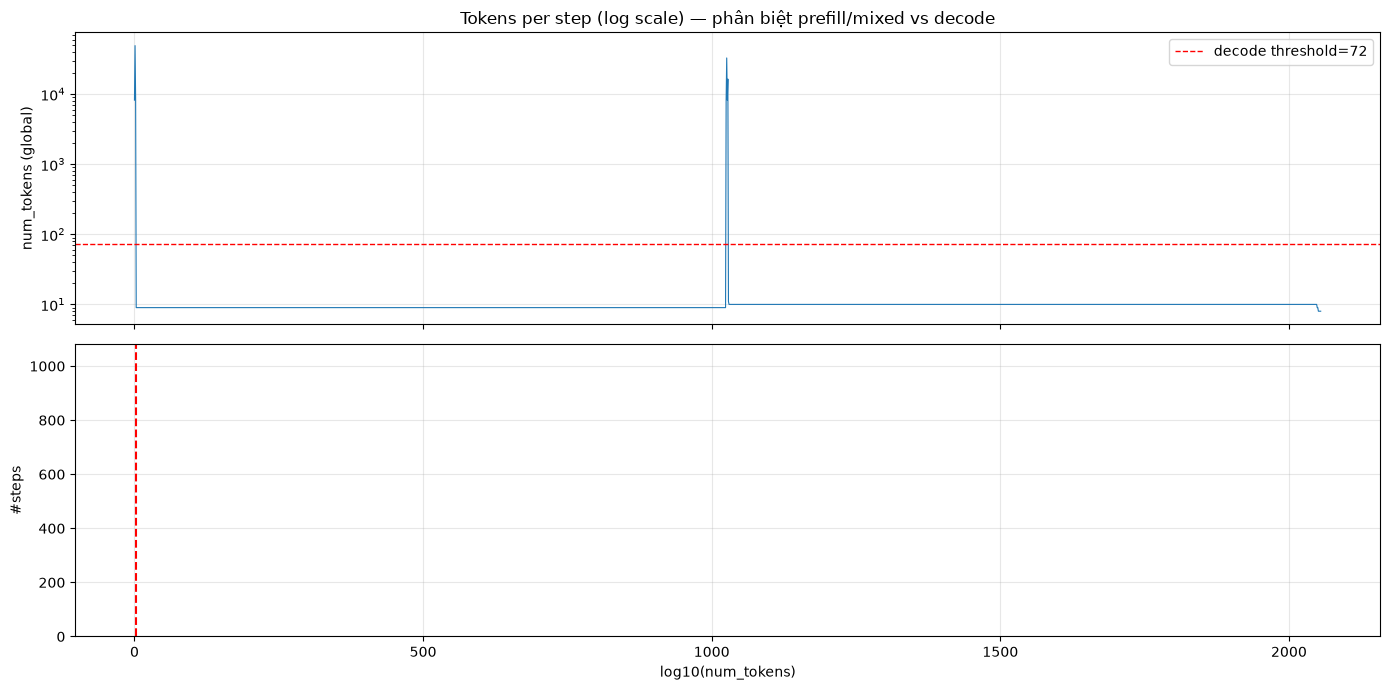

phase
decode           2049
prefill_mixed       7
Name: count, dtype: int64


In [5]:
# =============================================================================
# CELL 6 — SANITY CHECK: tokens/step theo thời gian + histogram phân bố.
# Mục đích: nhìn ra 2 cụm (decode ~ conc, prefill ~ hàng nghìn) để CHỌN ĐÚNG
# ngưỡng DECODE_MAX_TOKENS ở CELL 1.
# =============================================================================

# Gộp steps_df theo `step` (mọi layer cùng step có cùng num_tokens global).
#   num_tokens : lấy mean (thực chất giống nhau across layer)
#   imb_mean   : imbalance trung bình QUA CÁC LAYER tại step đó
#   imb_max    : imbalance layer tệ nhất tại step đó
per_step = steps_df.groupby("step").agg(
    num_tokens=("num_tokens", "mean"),
    imb_mean=("rank_max_over_min", "mean"),
    imb_max=("rank_max_over_min", "max"),
    imb_maxavg_mean=("rank_max_over_avg", "mean"),
).reset_index()
per_step["phase"] = np.where(per_step["num_tokens"] <= DECODE_MAX_TOKENS, "decode", "prefill_mixed")

# --- Vẽ 2 panel ---
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
# (trên) num_tokens theo step, trục y log để thấy cả decode (nhỏ) lẫn prefill (lớn).
ax[0].plot(per_step["step"], per_step["num_tokens"], lw=0.8)
ax[0].axhline(DECODE_MAX_TOKENS, color="r", ls="--", lw=1, label=f"decode threshold={DECODE_MAX_TOKENS}")
ax[0].set_ylabel("num_tokens (global)"); ax[0].set_yscale("log"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_title("Tokens per step (log scale) — phân biệt prefill/mixed vs decode")
# (dưới) histogram log10(num_tokens): 2 đỉnh tách biệt => ngưỡng nằm ở thung lũng giữa.
ax[1].hist(np.log10(per_step["num_tokens"].clip(lower=1)), bins=60, color="#888")
ax[1].axvline(np.log10(DECODE_MAX_TOKENS), color="r", ls="--")
ax[1].set_xlabel("log10(num_tokens)"); ax[1].set_ylabel("#steps"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(per_step["phase"].value_counts())   # đếm step mỗi phase sau khi chọn ngưỡng

## 3. Imbalance summary (all / prefill+mixed / decode)
Thống kê trên tất cả mẫu `(layer, step)`.

In [20]:
# =============================================================================
# CELL 8 — BẢNG SUMMARY: thống kê imbalance cho all / decode / prefill_mixed.
# Đây là các con số headline để báo cáo ticket.
# =============================================================================

def summarize(s):
    """Thống kê mô tả 1 mảng giá trị imbalance."""
    if len(s) == 0:
        return {}
    return {
        "n": len(s),
        "mean": float(np.mean(s)),
        "median": float(np.median(s)),
        "p90": float(np.percentile(s, 90)),
        "p99": float(np.percentile(s, 99)),
        "max": float(np.max(s)),
    }

def block(df):
    """Gói thống kê cho 1 subset (vd chỉ các step decode)."""
    return {
        "steps": int(df["step"].nunique()),               # số step phân biệt
        "samples(layer,step)": len(df),                    # số mẫu (mỗi layer mỗi step)
        "rank_max/min": summarize(df["rank_max_over_min"].values),
        "rank_max/avg": summarize(df["rank_max_over_avg"].values),
        "expert_max/avg": summarize(df["expert_max_over_avg"].values),
    }

# Dict tổng hợp -> sẽ được dump ra summary.json ở CELL 16.
summary = {
    "config": {"model": "GLM-5.2-FP8", "E": E, "R": R, "experts_per_rank": EXPERTS_PER_RANK,
                "topk": TOPK, "concurrency": CONCURRENCY, "decode_max_tokens": DECODE_MAX_TOKENS,
                "log": LOG_PATH},
    "all": block(steps_df),
    "decode": block(steps_df[steps_df.phase == "decode"]),
    "prefill_mixed": block(steps_df[steps_df.phase == "prefill_mixed"]),
}

def fmt(b, name):
    """In gọn 1 block thống kê ra console."""
    if not b or not b.get("rank_max/min"):
        print(f"  {name:14s}: (none)"); return
    rm = b["rank_max/min"]; ra = b["rank_max/avg"]
    print(f"  {name:14s}: steps={b['steps']:5d}  max/min mean={rm['mean']:.2f} "
          f"med={rm['median']:.2f} p99={rm['p99']:.2f} max={rm['max']:.2f}  |  "
          f"max/avg mean={ra['mean']:.3f} p99={ra['p99']:.3f}")

print(f"=== EP imbalance (max_token/min_token over {R} ranks) === {LOG_PATH}")
fmt(summary["decode"], "decode")
fmt(summary["prefill_mixed"], "prefill/mixed")
fmt(summary["all"], "all")

=== EP imbalance (max_token/min_token over 8 ranks) === /home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_bench/20260625_040651_8k_c8/serve.log
  decode        : steps= 2049  max/min mean=3.81 med=3.00 p99=17.00 max=40.00  |  max/avg mean=1.574 p99=2.222
  prefill/mixed : steps=    7  max/min mean=2.24 med=1.71 p99=12.02 max=76.50  |  max/avg mean=1.352 p99=2.001
  all           : steps= 2056  max/min mean=3.80 med=3.00 p99=17.00 max=76.50  |  max/avg mean=1.573 p99=2.222


## 4. Imbalance over steps (prefill vs decode)

ValueError: x and y must have same first dimension, but have shapes (7,) and (10,)

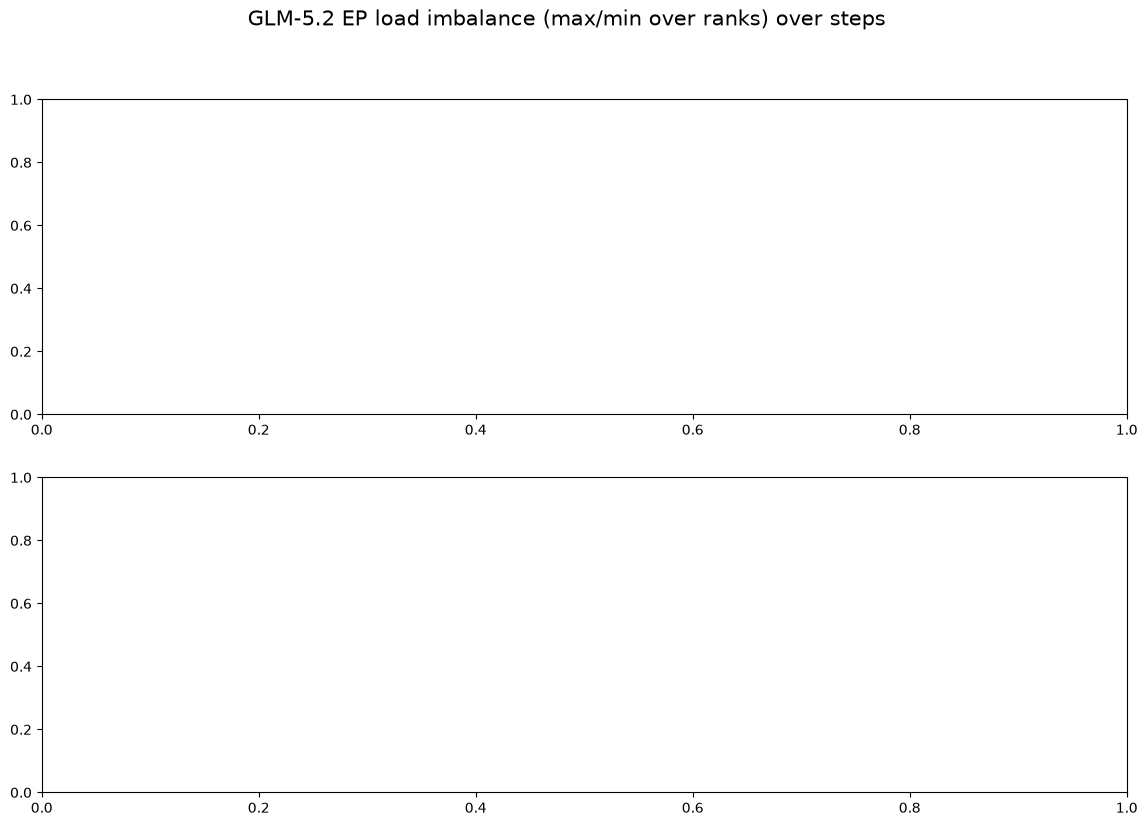

In [41]:
# =============================================================================
# CELL 10 — IMBALANCE THEO STEP (tách prefill vs decode) + phân phối gap.
# =============================================================================

def smoothen(x, w=10):
    """Moving-average cửa sổ w để đường đỡ nhiễu (chỉ để nhìn xu hướng)."""
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x
    k = np.ones(w) / w
    return np.convolve(x, k, mode="same")

# Tách per_step (đã gộp theo step ở CELL 6) thành 2 nhóm phase, sort theo step.
dec = per_step[per_step.phase == "decode"].sort_values("step")
pre = per_step[per_step.phase == "prefill_mixed"].sort_values("step")
W = 10   # cửa sổ smoothing

# --- 2 panel: imbalance(max/min) theo step, mean & max qua layer ---
fig, ax = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("GLM-5.2 EP load imbalance (max/min over ranks) over steps", fontsize=15, y=0.98)
ax[0].plot(pre["step"], smoothen(pre["imb_mean"], W), color="#1f77b4", label="mean over layers")
ax[0].plot(pre["step"], smoothen(pre["imb_max"], W), color="#1f77b4", alpha=.35, label="max over layers")
ax[0].set_title("Prefill/Mixed"); ax[0].set_ylabel("max/min"); ax[0].grid(alpha=.3); ax[0].legend(loc="upper left")
ax[1].plot(dec["step"], smoothen(dec["imb_mean"], W), color="#ff7f0e", label="mean over layers")
ax[1].plot(dec["step"], smoothen(dec["imb_max"], W), color="#ff7f0e", alpha=.35, label="max over layers")
ax[1].set_title("Decode"); ax[1].set_xlabel("step"); ax[1].set_ylabel("max/min"); ax[1].grid(alpha=.3); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

# --- Phân phối giá trị imbalance (mỗi mẫu = 1 (layer,step)) cho từng phase ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, ph, c in [(ax[0], "decode", "#ff7f0e"), (ax[1], "prefill_mixed", "#1f77b4")]:
    d = steps_df[steps_df.phase == ph]["rank_max_over_min"]
    a.hist(d, bins=40, color=c, edgecolor="k", alpha=.8)
    a.set_title(f"{ph}: max/min distribution (n={len(d)})")
    a.set_xlabel("max/min"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Global load distribution (end-to-end, toàn run)
Tổng trên toàn bộ (layer, step) — cho thấy expert / rank nào bị dồn tải.

1


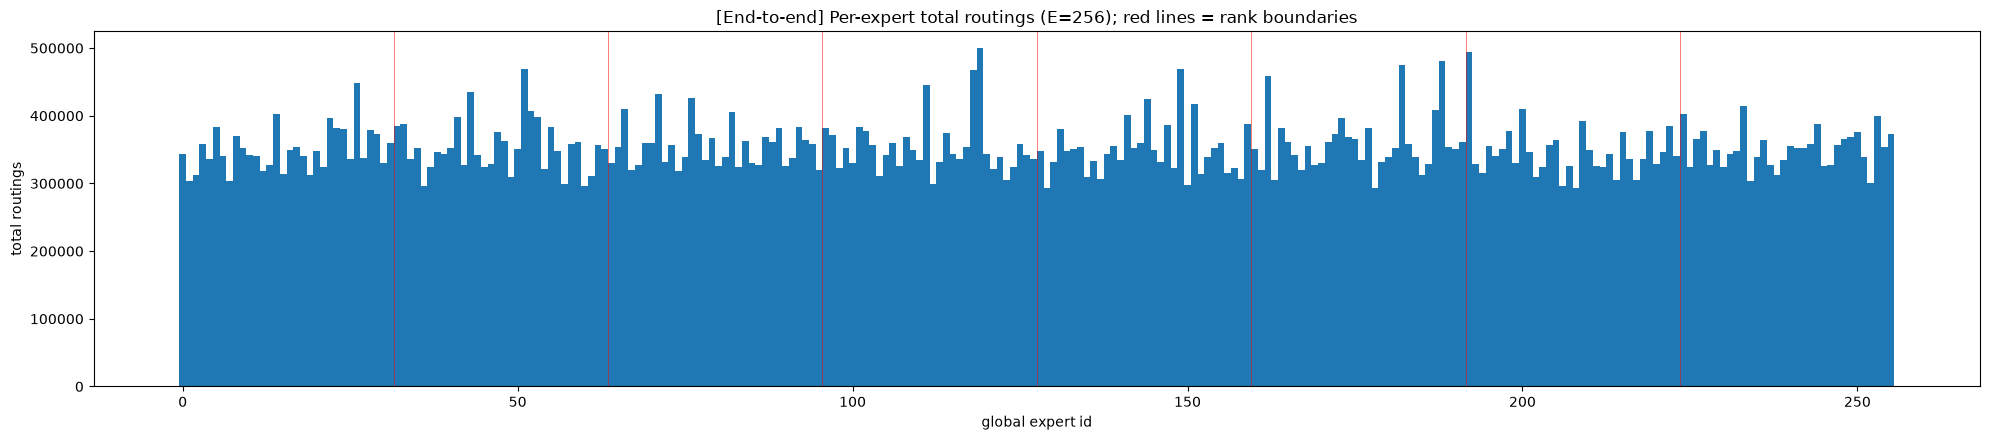

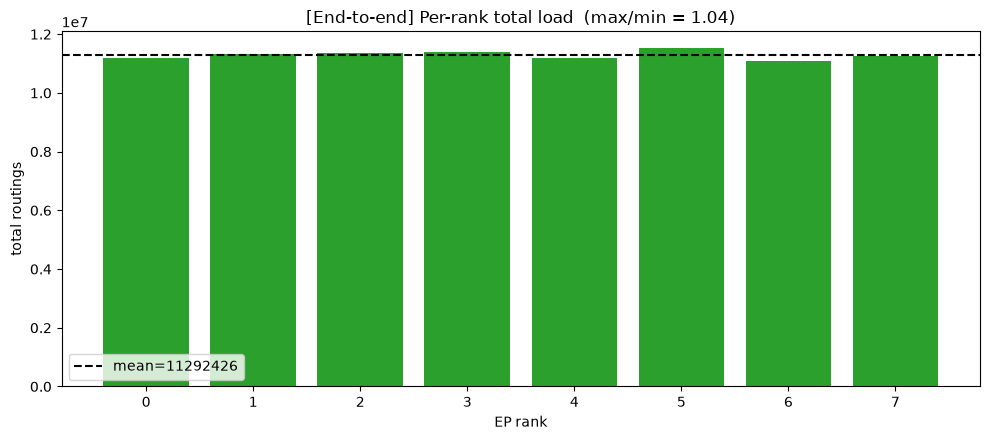

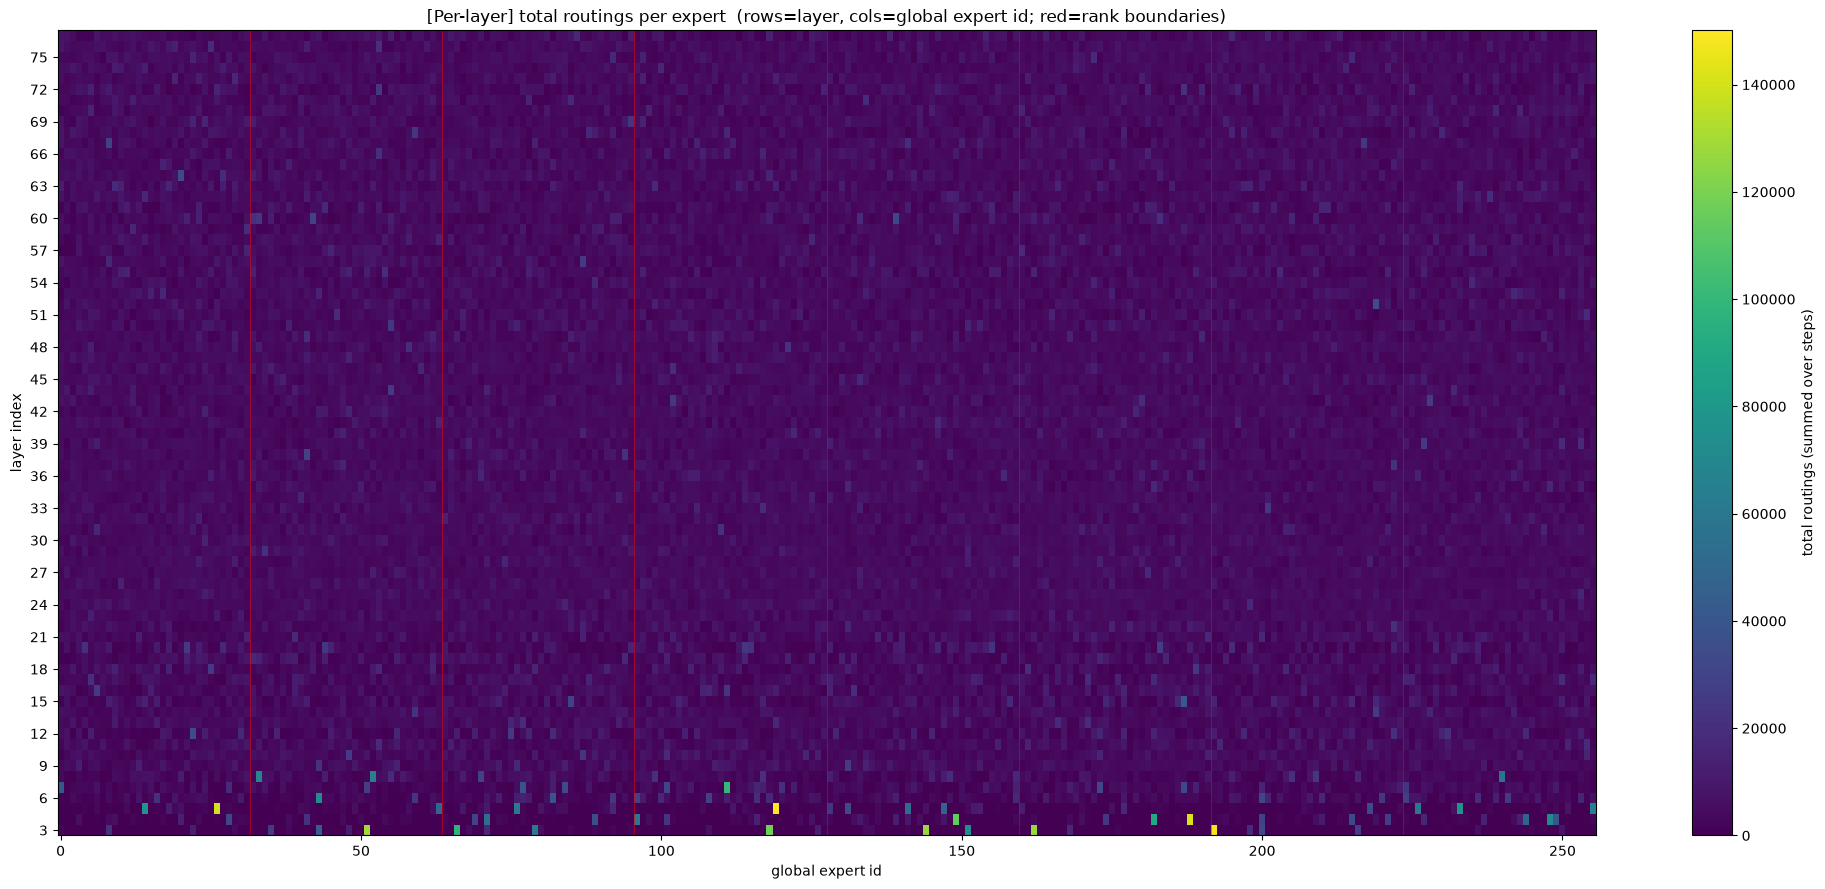

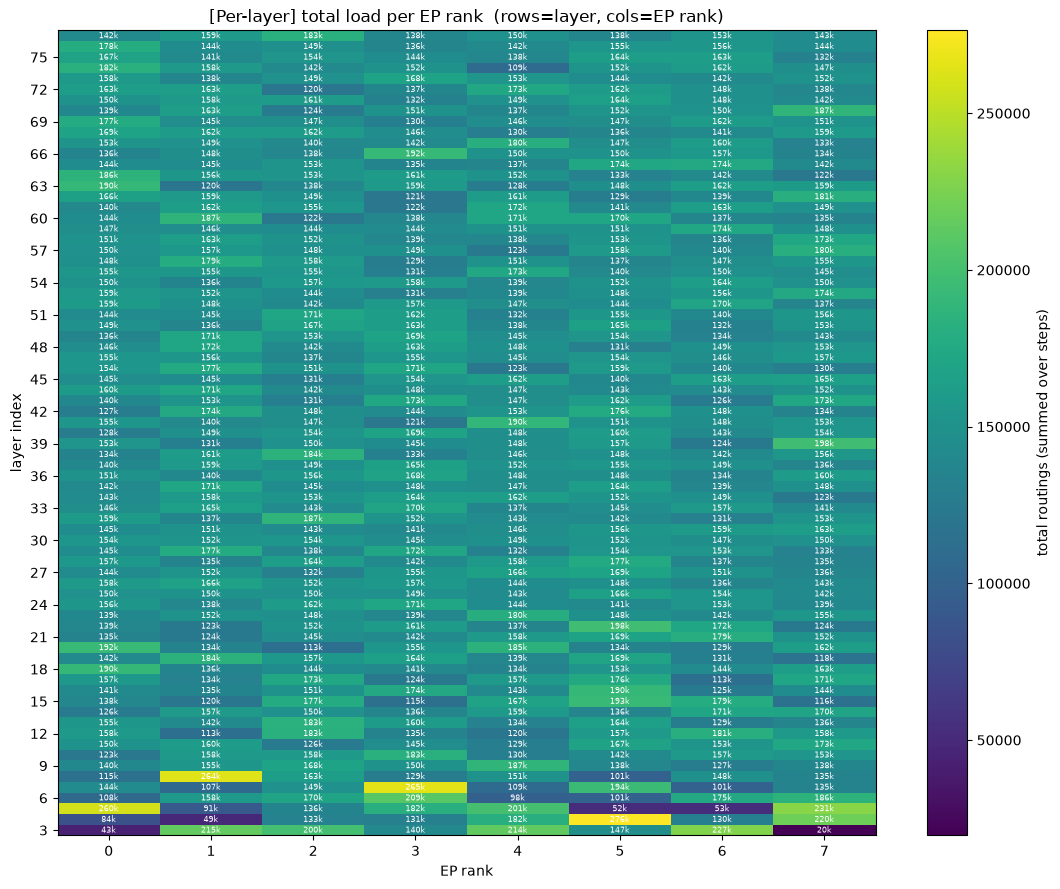

In [7]:
# =============================================================================
# CELL 12 — PHÂN PHỐI TẢI (#token-routing).
#   Phần A: tổng TOÀN RUN (end-to-end) -> 2 figure riêng: per-expert & per-rank.
#   Phần B: tách theo TỪNG LAYER -> heatmap (layer x expert) & (layer x rank),
#           mỗi ô = tổng routing của expert/rank đó tại layer đó qua MỌI step.
# =============================================================================

# ---- build ma trận per-layer: M[layer, expert] = Σ_step counts (chỉ group đủ R rank) ----
expert_dist_by_layer = {}                       # layer -> np.array[E]
cnt = 0
for (lidx, step), counts in agg.items():
    if len(agg_ranks[(lidx, step)]) != R:       # giống CELL 4: chỉ lấy group đủ rank
        # assert False, len(agg_ranks[(lidx, step)])
        cnt += 1
        continue
    if lidx not in expert_dist_by_layer:
        expert_dist_by_layer[lidx] = np.zeros(E, dtype=np.int64)
    expert_dist_by_layer[lidx] += counts
print(cnt)

layers_sorted = sorted(expert_dist_by_layer)                       # vd [3,4,...,77]
M_expert = np.stack([expert_dist_by_layer[l] for l in layers_sorted])      # (L, E)
M_rank   = M_expert.reshape(len(layers_sorted), R, E // R).sum(axis=2)     # (L, R)

# ============================ PHẦN A: end-to-end ============================
rank_dist = rank_loads(expert_dist_global, R)   # tải tổng mỗi rank cả run

# --- Figure A1: per-expert (256 cột) ---
plt.figure(figsize=(20, 4.5))
plt.bar(range(E), expert_dist_global, width=1.0)
for r in range(1, R):
    plt.axvline(r * EXPERTS_PER_RANK - 0.5, color="r", lw=0.6, alpha=.6)
plt.title(f"[End-to-end] Per-expert total routings (E={E}); red lines = rank boundaries")
plt.xlabel("global expert id"); plt.ylabel("total routings")
plt.tight_layout(); plt.show()

# --- Figure A2: per-rank (8 cột) ---
plt.figure(figsize=(10, 4.5))
plt.bar(range(R), rank_dist, color="#2ca02c")
plt.axhline(rank_dist.mean(), color="k", ls="--", label=f"mean={rank_dist.mean():.0f}")
plt.title(f"[End-to-end] Per-rank total load  (max/min = {rank_dist.max()/max(rank_dist.min(),1):.2f})")
plt.xlabel("EP rank"); plt.ylabel("total routings"); plt.legend()
plt.tight_layout(); plt.show()

# ============================ PHẦN B: theo từng layer ============================
# y-tick: hiển thị 1 nhãn layer mỗi `ystep` hàng cho đỡ rối.
ystep = max(1, len(layers_sorted) // 25)
yt = range(0, len(layers_sorted), ystep)
ytl = [layers_sorted[i] for i in yt]

# --- Figure B1: heatmap (layer x expert) ---
plt.figure(figsize=(20, 9))
plt.imshow(M_expert, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
for r in range(1, R):
    plt.axvline(r * EXPERTS_PER_RANK - 0.5, color="r", lw=0.6, alpha=.6)
plt.colorbar(label="total routings (summed over steps)")
plt.yticks(list(yt), ytl)
plt.title("[Per-layer] total routings per expert  (rows=layer, cols=global expert id; red=rank boundaries)")
plt.xlabel("global expert id"); plt.ylabel("layer index")
plt.tight_layout(); plt.show()

# --- Figure B2: heatmap (layer x rank) ---
plt.figure(figsize=(11, 9))
plt.imshow(M_rank, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
plt.colorbar(label="total routings (summed over steps)")
plt.yticks(list(yt), ytl)
plt.xticks(range(R), range(R))
plt.title("[Per-layer] total load per EP rank  (rows=layer, cols=EP rank)")
plt.xlabel("EP rank"); plt.ylabel("layer index")
# annotate giá trị nếu lưới không quá lớn
if len(layers_sorted) <= 80:
    for i in range(len(layers_sorted)):
        for j in range(R):
            plt.text(j, i, f"{M_rank[i, j]/1e6:.1f}M" if M_rank[i, j] >= 1e6 else f"{M_rank[i, j]/1e3:.0f}k",
                     ha="center", va="center", color="w", fontsize=6)
plt.tight_layout(); plt.show()

/tmp/ipykernel_341623/2548639850.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xlabel("EP rank"); plt.ylabel("total routings"); plt.xticks(range(R)); plt.legend()


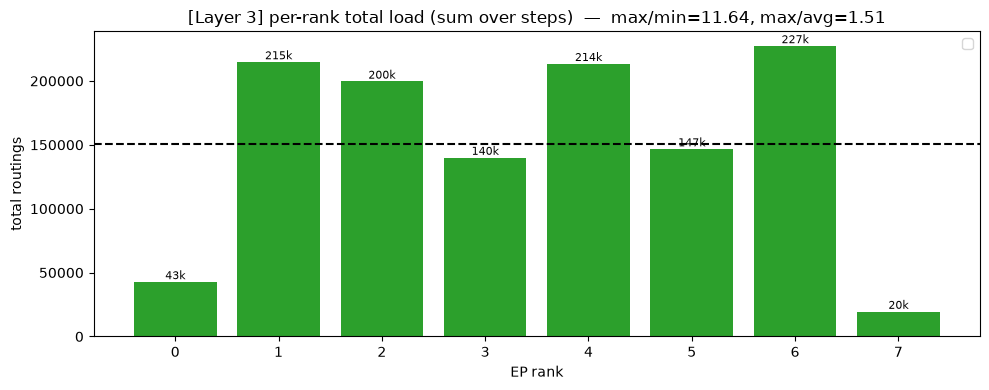

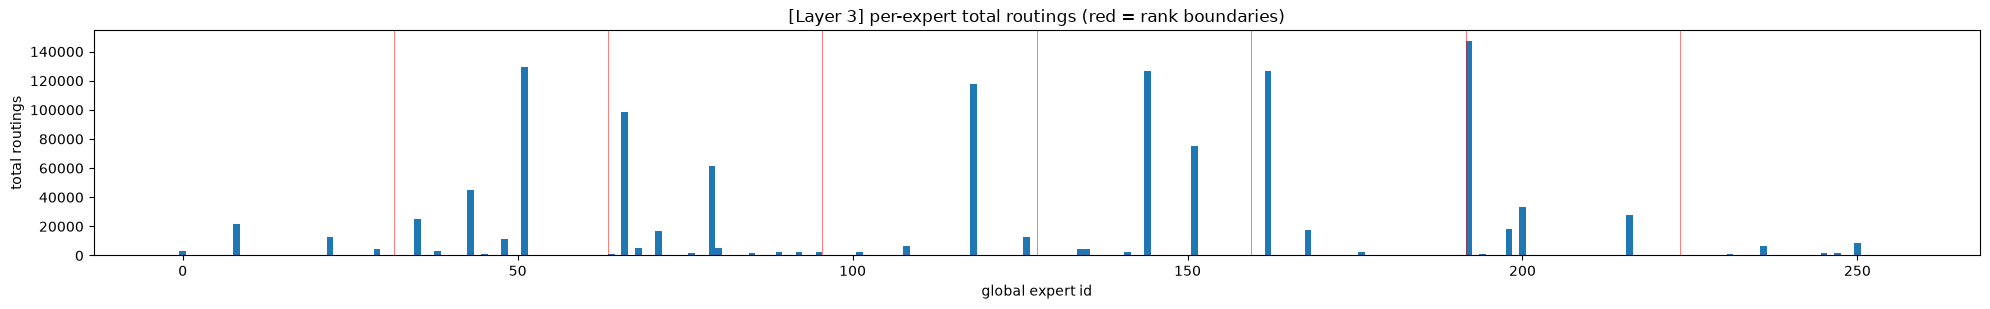

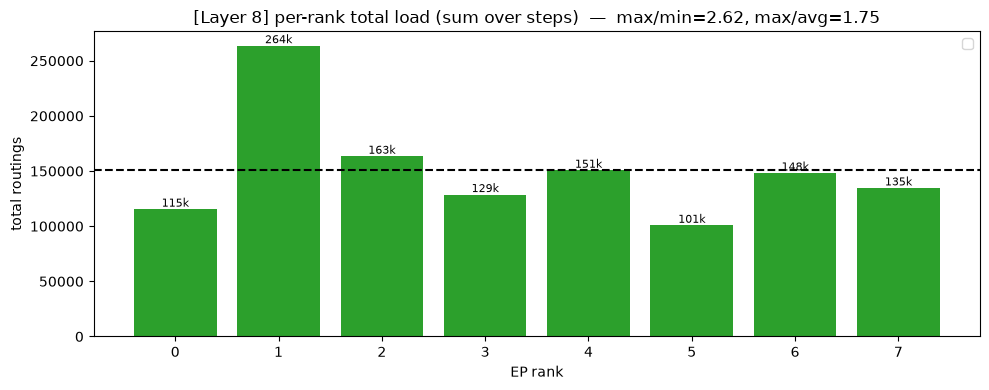

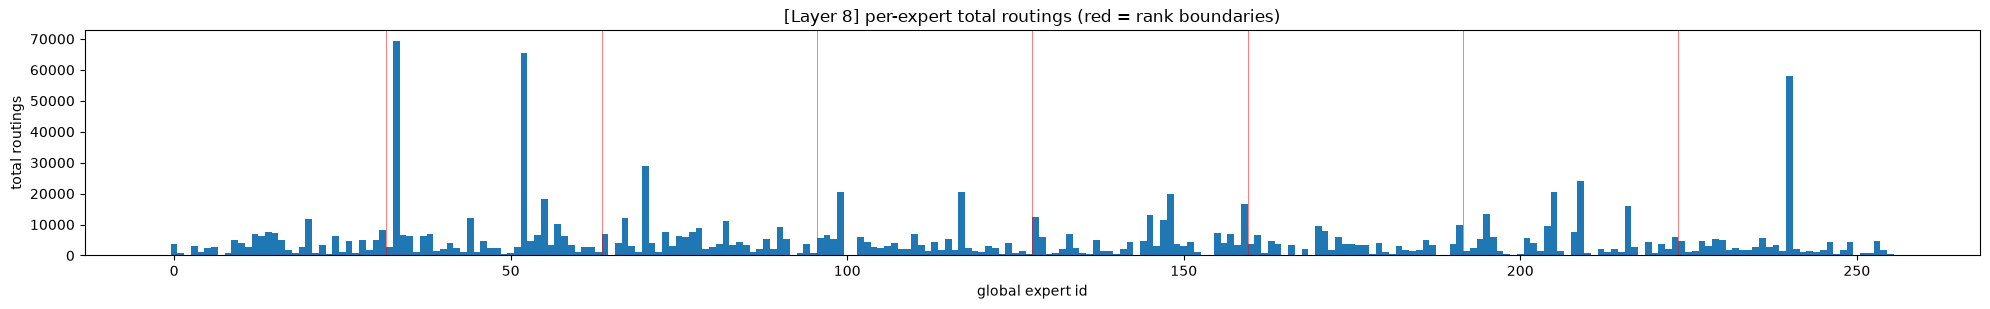

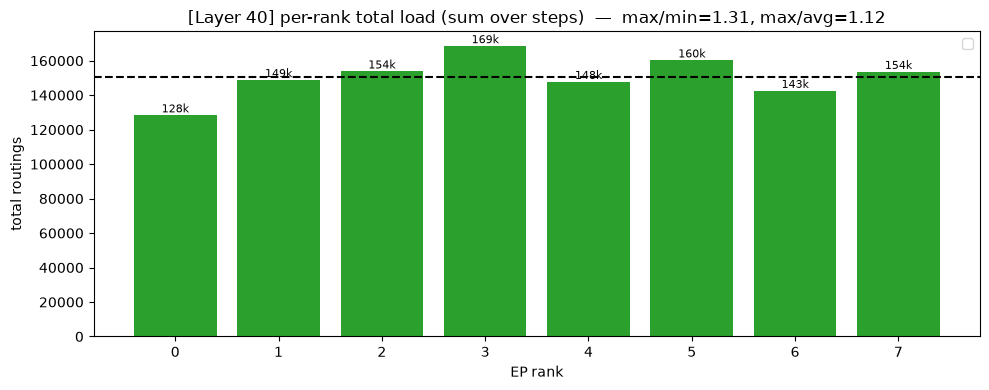

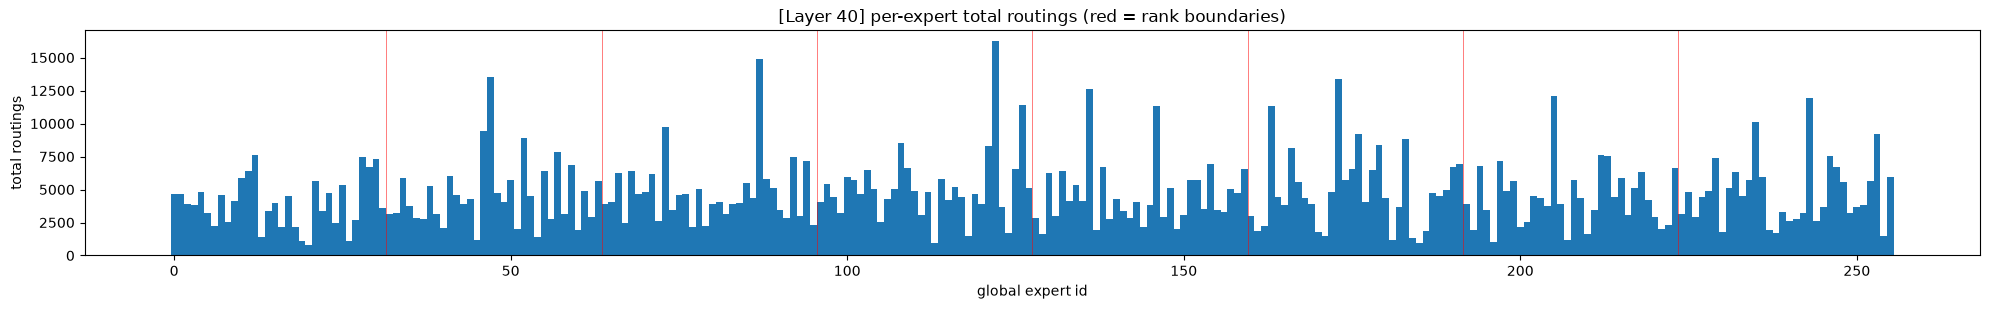

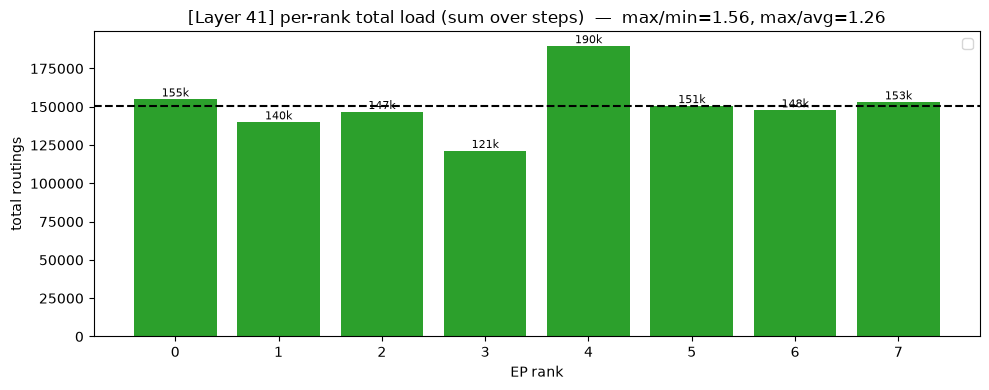

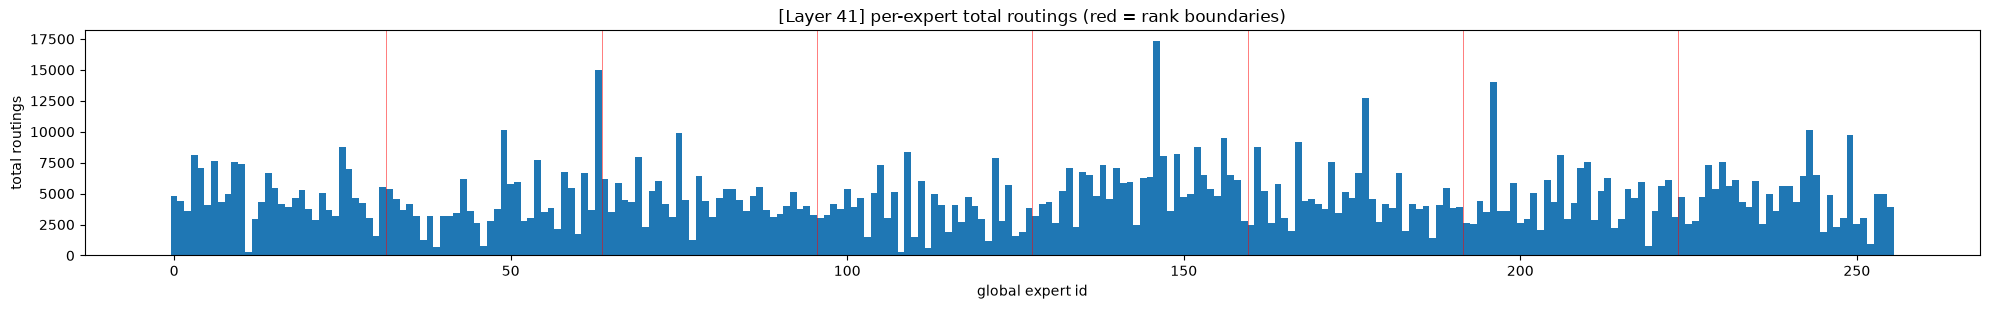

In [8]:
# =============================================================================
# CELL 13 — Per-rank total load cho TỪNG LAYER cụ thể (bar, giống chart A2 end-to-end
# nhưng tách riêng từng layer). Dùng để soi layer đầu (imbalance cao) vs layer giữa.
# Dùng expert_dist_by_layer đã build ở CELL 12.
# =============================================================================
LAYERS_TO_PLOT = [3, 8, 40, 41]      # chỉnh tuỳ ý: layer đầu lệch mạnh vs layer giữa cân hơn

for L in LAYERS_TO_PLOT:
    if L not in expert_dist_by_layer:
        print(f"layer {L}: không có dữ liệu"); continue
    vec = expert_dist_by_layer[L]                 # [256] tổng routing mỗi expert qua mọi step (layer L)
    loads = rank_loads(vec, R)                     # [8]  tổng routing mỗi EP rank
    mm = loads.max() / max(loads.min(), 1)
    ma = loads.max() / loads.mean()

    # --- per-rank bar (cái bạn cần) ---
    plt.figure(figsize=(10, 4))
    bars = plt.bar(range(R), loads, color="#2ca02c")
    plt.axhline(loads.mean(), color="k", ls="--", label=f"")
    for j, v in enumerate(loads):                  # ghi giá trị trên cột
        plt.text(j, v, f"{v/1e6:.2f}M" if v >= 1e6 else f"{v/1e3:.0f}k", ha="center", va="bottom", fontsize=8)
    plt.title(f"[Layer {L}] per-rank total load (sum over steps)  —  max/min={mm:.2f}, max/avg={ma:.2f}")
    plt.xlabel("EP rank"); plt.ylabel("total routings"); plt.xticks(range(R)); plt.legend()
    plt.tight_layout(); plt.show()

    # --- per-expert bar (để thấy expert nào gây lệch) ---
    plt.figure(figsize=(20, 3.2))
    plt.bar(range(E), vec, width=1.0)
    for r in range(1, R):
        plt.axvline(r * EXPERTS_PER_RANK - 0.5, color="r", lw=0.6, alpha=.6)
    plt.title(f"[Layer {L}] per-expert total routings (red = rank boundaries)")
    plt.xlabel("global expert id"); plt.ylabel("total routings")
    plt.tight_layout(); plt.show()

## 6. Per-layer imbalance
Layer nào imbalance nặng nhất? (tách theo phase)

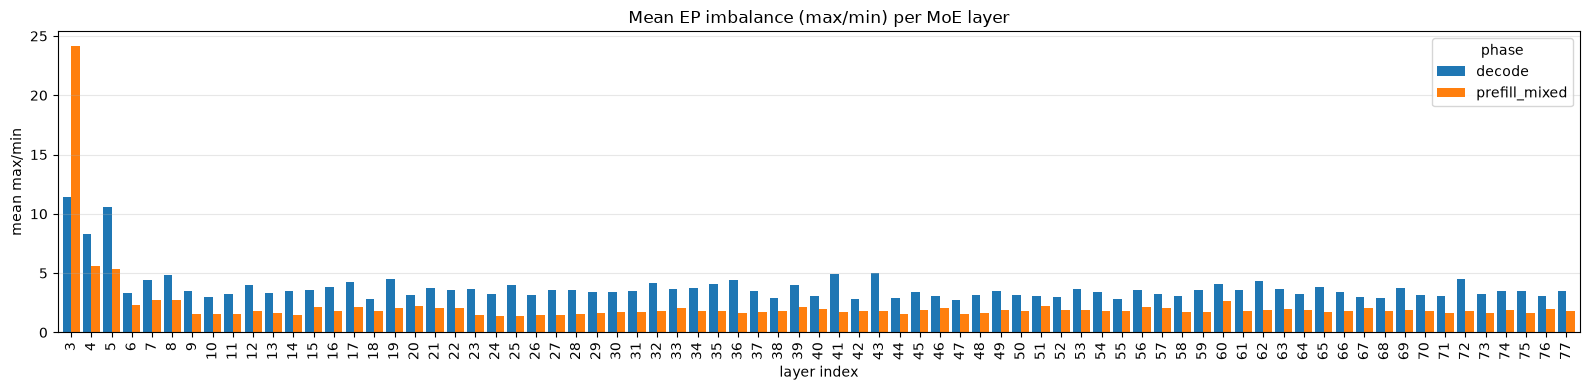

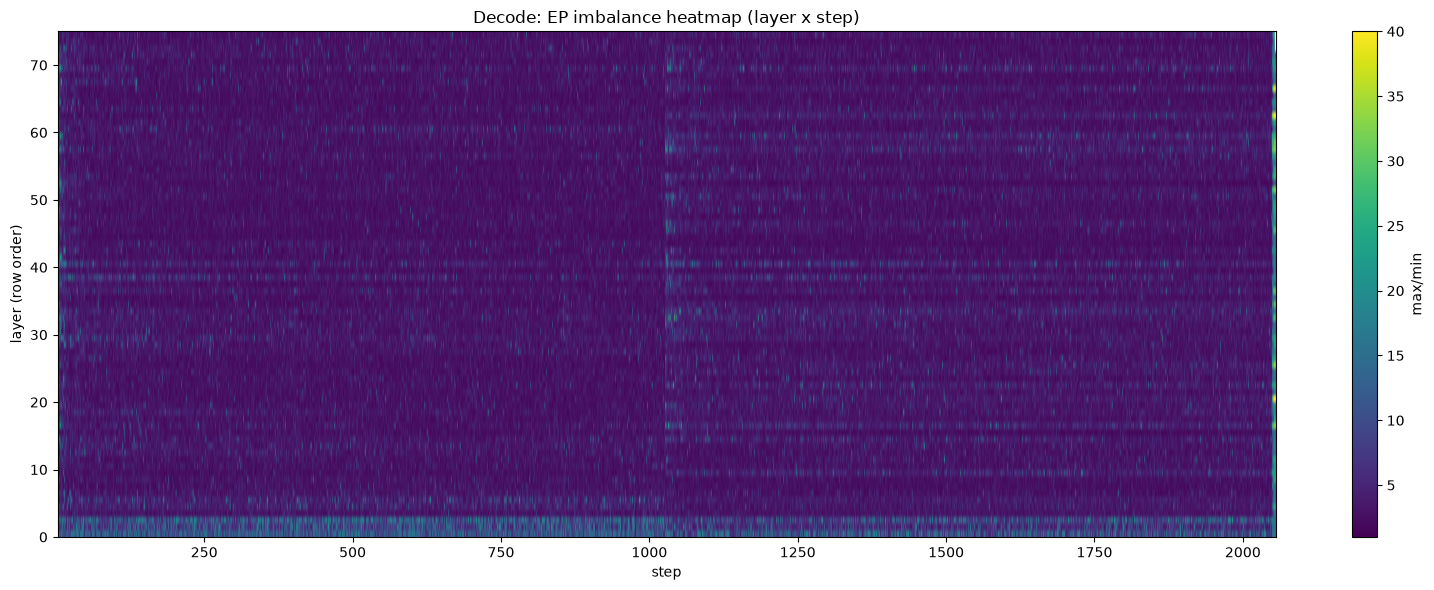

In [ ]:
# =============================================================================
# CELL 14 — PHÂN TÍCH THEO LAYER: layer nào lệch nặng nhất + biến thiên theo thời gian.
# =============================================================================

# Bar: imbalance trung bình mỗi MoE-layer, tách 2 cột decode/prefill.
#   groupby(layer, phase) -> mean(max/min) -> unstack thành 2 cột để vẽ cạnh nhau.
per_layer = steps_df.groupby(["layer", "phase"])["rank_max_over_min"].mean().unstack("phase")
per_layer = per_layer.reindex(sorted(per_layer.index))
ax = per_layer.plot(kind="bar", figsize=(16, 4), width=0.85)
ax.set_title("Mean EP imbalance (max/min) per MoE layer")
ax.set_xlabel("layer index"); ax.set_ylabel("mean max/min"); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

# Heatmap (layer x step) cho riêng phase decode:
#   pivot -> ma trận, mỗi ô = imbalance của (layer, step) đó.
#   Nhìn được cả layer nào nóng lẫn nó thay đổi thế nào theo thời gian decode.
dec_df = steps_df[steps_df.phase == "decode"]
print(dec_df)
if len(dec_df):
    piv = dec_df.pivot_table(index="layer", columns="step", values="rank_max_over_min")
    piv = piv.reindex(sorted(piv.index))
    plt.figure(figsize=(16, 6))
    plt.imshow(piv.values, aspect="auto", cmap="viridis", origin="lower",
               extent=[piv.columns.min(), piv.columns.max(), 0, len(piv.index)])
    plt.colorbar(label="max/min")
    plt.title("Decode: EP imbalance heatmap (layer x step)")
    plt.xlabel("step"); plt.ylabel("layer (row order)")
    plt.tight_layout(); plt.show()

## 7. Export

In [ ]:
# =============================================================================
# CELL 16 — EXPORT kết quả ra <log_dir>/ep_analysis/ để báo cáo / so sánh case.
# =============================================================================
OUT_DIR = os.path.join(os.path.dirname(LOG_PATH), "ep_analysis")
os.makedirs(OUT_DIR, exist_ok=True)

steps_df.to_parquet(os.path.join(OUT_DIR, "steps_imbalance.parquet"))   # bảng lõi (layer,step)
per_step.to_csv(os.path.join(OUT_DIR, "per_step.csv"), index=False)     # tổng hợp theo step
np.save(os.path.join(OUT_DIR, "expert_dist_global.npy"), expert_dist_global)  # phân phối expert toàn run
with open(os.path.join(OUT_DIR, "summary.json"), "w") as f:             # các số headline
    json.dump(summary, f, indent=2)

print("saved ->", OUT_DIR)
print(json.dumps(summary, indent=2)[:1500])

## 8. (Optional) Verify — đối chiếu `bincount` vs Python-loop

So sánh `[EP_COLLECT]` (dùng `torch.bincount`) với `[EP_COLLECT_DBG]` (đếm bằng vòng `for` thuần Python, giữ cả id < 0 / ≥ E) theo từng `(rank, layer, it)`.

**Điều kiện:** run phải bật cả `VLLM_MOREH_EP_LOG=1` **và** `VLLM_MOREH_EP_LOG_DEBUG=1` (nên dùng run nhỏ + `enforce_eager`, vì hàm debug chậm). Kỳ vọng: `mismatches=0`; nếu `n_neg=n_oob=0` thì `topk_ids` toàn id hợp lệ trong `[0, E)`.

In [ ]:
# =============================================================================
# CELL 18 — (OPTIONAL) VERIFY: bincount [EP_COLLECT] có khớp Python-loop [EP_COLLECT_DBG]?
# Chỉ chạy được nếu run đã bật CẢ HAI: VLLM_MOREH_EP_LOG=1 và VLLM_MOREH_EP_LOG_DEBUG=1.
# =============================================================================
# off-by-one của `it` (đã verify trên log 063000): bản chính tăng counter trước,
# debug đọc sau -> với CÙNG 1 forward, DBG it = EC it + 1.
#   - Log CŨ (trước fix fp8.py): DBG_IT_OFFSET = 1.
#   - Log MỚI (sau fix, it dùng chung): DBG_IT_OFFSET = 0.
# Ta ghép EC(rank,layer,it)  <->  DBG(rank,layer, it + DBG_IT_OFFSET).
DBG_IT_OFFSET = 1
import ast

VERIFY_LOG = "/home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_bench/20260625_063000/serve.log"

EC_RE  = re.compile(r"Worker_DP(\d+)_EP(\d+).*?\[EP_COLLECT\] layer=(\S+) it=(\d+) ntok=(\d+) E=(\d+) counts=\[")
DBG_RE = re.compile(r"Worker_DP(\d+)_EP(\d+).*?\[EP_COLLECT_DBG\] layer=(\S+) it=(\d+) shape=.*? E=(\d+) n_neg=(\d+) n_oob=(\d+) ")

# --- gom [EP_COLLECT]: (rank, layer, it) -> vector counts[E] (từ bincount) ---
ec = {}
for line in open(VERIFY_LOG, errors="ignore"):
    m = EC_RE.search(line)
    if not m:
        continue
    rank = int(m.group(2)); lname = m.group(3); it = int(m.group(4)); E_ = int(m.group(6))
    start = m.end(); rb = line.find("]", start)
    if rb == -1:
        continue
    counts = np.array(line[start:rb].split(","), dtype=np.int64)
    if counts.shape[0] == E_:
        ec[(rank, lname, it)] = counts

# --- gom [EP_COLLECT_DBG]: (rank, layer, it) -> (hist dict, n_neg, n_oob) (từ Python loop) ---
dbg = {}
for line in open(VERIFY_LOG, errors="ignore"):
    m = DBG_RE.search(line)
    if not m:
        continue
    rank = int(m.group(2)); lname = m.group(3); it = int(m.group(4))
    n_neg = int(m.group(6)); n_oob = int(m.group(7))
    hs = line.find("hist=", m.end())          # hist={...} là field cuối -> literal_eval phần đuôi
    if hs == -1:
        continue
    try:
        hist = ast.literal_eval(line[hs + 5:].strip())
    except Exception:
        continue
    dbg[(rank, lname, it)] = (hist, n_neg, n_oob)

# --- ghép cặp EC[(r,l,it)] <-> DBG[(r,l,it + DBG_IT_OFFSET)] ---
pairs = []
for (rank, lname, it) in ec:
    k_dbg = (rank, lname, it + DBG_IT_OFFSET)
    if k_dbg in dbg:
        pairs.append(((rank, lname, it), k_dbg))
print(f"[EP_COLLECT] lines={len(ec)}  [EP_COLLECT_DBG] lines={len(dbg)}  "
      f"paired (DBG_IT_OFFSET={DBG_IT_OFFSET})={len(pairs)}")

if not pairs:
    print("=> Không ghép được cặp nào. Thử DBG_IT_OFFSET khác (0 cho log mới), "
          "hoặc kiểm tra run đã bật cả VLLM_MOREH_EP_LOG=1 và VLLM_MOREH_EP_LOG_DEBUG=1 chưa.")
else:
    mismatches = 0; tot_neg = 0; tot_oob = 0
    for k_ec, k_dbg in pairs:
        counts = ec[k_ec]
        hist, n_neg, n_oob = dbg[k_dbg]
        tot_neg += n_neg; tot_oob += n_oob
        E_ = counts.shape[0]
        # Dựng lại vector dense từ hist, CHỈ lấy expert id trong [0, E) (giống mask `valid`).
        dense = np.zeros(E_, dtype=np.int64)
        for e, c in hist.items():
            if 0 <= e < E_:
                dense[e] = c
        # (1) từng expert phải khớp
        if not np.array_equal(dense, counts):
            mismatches += 1
            if mismatches <= 5:
                diff = np.where(dense != counts)[0]
                print(f"  MISMATCH EC{k_ec} vs DBG{k_dbg}: experts={diff[:10].tolist()} "
                      f"dbg={dense[diff[:10]].tolist()} bincount={counts[diff[:10]].tolist()}")
        # (2) tổng in-range phải khớp
        in_range_sum = sum(c for e, c in hist.items() if 0 <= e < E_)
        if in_range_sum != counts.sum():
            mismatches += 1
            if mismatches <= 5:
                print(f"  SUM MISMATCH EC{k_ec} vs DBG{k_dbg}: {in_range_sum} != {counts.sum()}")

    print(f"checked {len(pairs)} pairs:  mismatches={mismatches}  "
          f"tổng n_neg(slot<0)={tot_neg}  tổng n_oob(slot>=E)={tot_oob}")
    if mismatches == 0:
        print("OK ✅ bincount khớp 100% với Python-loop. "
              "Nếu n_neg=n_oob=0 => topk_ids toàn id hợp lệ trong [0,E), mask `valid` không vứt nhầm gì.")

## 9. Ngưỡng chia decode/prefill = AUTO (thay 4xconc) — [MV-4571 new-split]

`num_tokens` mỗi (layer,step) lưỡng cực: **decode** nhỏ, **prefill** hàng nghìn, có khe trống lớn ở
giữa. `auto` = trung điểm hình học của khe log lớn nhất → cắt ở vùng trống, không xẻ đôi cụm.
4xconc SAI cho MTP (decode ≈ 6–15×conc → bị cắt nhầm sang prefill); non-MTP thì 4x/6x/auto trùng nhau.

In [ ]:
# [MV-4571 new-split] auto threshold + so sánh với 4x/6x trên 1 parquet
import numpy as np, pandas as pd, glob, re
def auto_decode_threshold(num_tokens):
    u = np.unique(np.asarray(num_tokens, dtype=np.int64)); u = u[u > 0]
    if len(u) < 2: return (float(u.max()) + 1) if len(u) else 1.0
    j = int(np.argmax(np.diff(np.log10(u.astype(float)))))   # khe log lớn nhất
    return float(np.sqrt(u[j] * u[j + 1]))                   # trung điểm hình học
P = sorted(glob.glob("**/tokens/analysis/steps_imbalance.parquet", recursive=True))
if P:
    p = P[0]; conc = int(re.search(r"_c(\d+)", p).group(1)); nt = pd.read_parquet(p)["num_tokens"].values
    thr = auto_decode_threshold(nt)
    print(p)
    for name, t in [("auto", thr), ("4xconc", 4*conc), ("6xconc", 6*conc)]:
        print(f"  {name:7} thr={t:8.1f}  decode={int((nt<=t).sum()):7d}/{len(nt)}")
